In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
%matplotlib inline

In [2]:
df = pd.read_csv('dataset.csv')
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4.0,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4.0,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4.0,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3.0,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4.0,acoustic


In [3]:
# 1. Inspect structure and data types
print("--- Dataset Info ---")
df.info()

# 2. Check numerical vs categorical columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nNumerical Columns ({len(num_cols)}):", num_cols)
print(f"Categorical Columns ({len(cat_cols)}):", cat_cols)

# 3. Descriptive statistical analysis
print("\n--- Summary Statistics ---")
display(df.describe())

# 4. Check missing values & duplicate records
print("\nMissing Values:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("\nDuplicate Rows:", df.duplicated().sum())

# Clean missing/duplicate records if needed
df = df.drop_duplicates()
df = df.dropna()

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59971 entries, 0 to 59970
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        59971 non-null  int64  
 1   track_id          59971 non-null  object 
 2   artists           59971 non-null  object 
 3   album_name        59971 non-null  object 
 4   track_name        59971 non-null  object 
 5   popularity        59971 non-null  int64  
 6   duration_ms       59971 non-null  int64  
 7   explicit          59971 non-null  bool   
 8   danceability      59971 non-null  float64
 9   energy            59971 non-null  float64
 10  key               59971 non-null  int64  
 11  loudness          59971 non-null  float64
 12  mode              59971 non-null  int64  
 13  speechiness       59971 non-null  float64
 14  acousticness      59971 non-null  float64
 15  instrumentalness  59971 non-null  float64
 16  liveness          5

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,59971.000000,59971.000000,5.997100e+04,59971.000000,59971.000000,59971.000000,59971.000000,59971.000000,59971.000000,59971.000000,59971.000000,59971.000000,59971.00000,59971.000000,59970.000000
mean,29985.000000,32.526471,2.304434e+05,0.561872,0.658705,5.337813,-8.135897,0.630238,0.092417,0.283254,0.186475,0.208736,0.44837,123.058683,3.910805
std,17312.280834,22.375109,1.163604e+05,0.176105,0.251528,3.563084,4.960762,0.482744,0.125333,0.326911,0.328507,0.183116,0.25518,29.274467,0.412496
min,0.000000,0.000000,8.586000e+03,0.000000,0.000020,0.000000,-42.044000,0.000000,0.000000,0.000000,0.000000,0.011200,0.00000,0.000000,0.000000
25%,14992.500000,15.000000,1.734795e+05,0.448000,0.491000,2.000000,-9.876000,0.000000,0.036400,0.008245,0.000000,0.097100,0.23600,100.090500,4.000000
50%,29985.000000,32.000000,2.133060e+05,0.574000,0.706000,6.000000,-6.835000,1.000000,0.050400,0.119000,0.000185,0.131000,0.42800,122.992000,4.000000
75%,44977.500000,50.000000,2.657665e+05,0.693000,0.872000,8.000000,-4.918000,1.000000,0.090100,0.534000,0.181500,0.269000,0.64800,140.985000,4.000000
max,59970.000000,100.000000,4.789026e+06,0.983000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,0.999000,0.995000,0.99500,243.372000,5.000000



Missing Values:
 time_signature    1
track_genre       1
dtype: int64

Duplicate Rows: 0


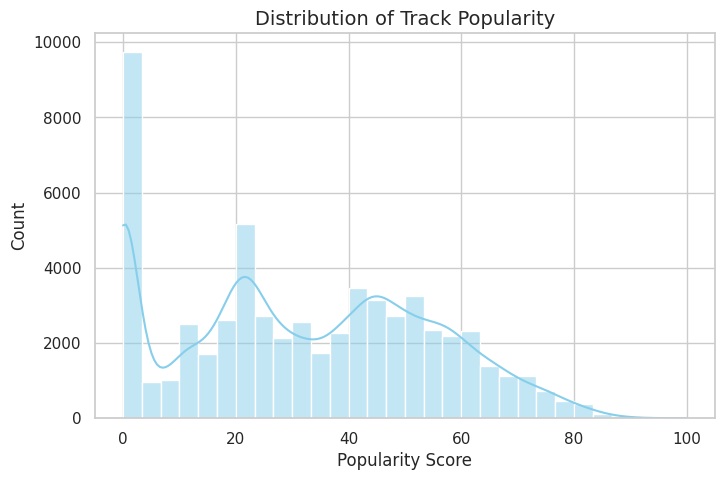

In [4]:
plt.figure(figsize=(8, 5))
sns.histplot(df['popularity'], kde=True, color='skyblue', bins=30)
plt.title('Distribution of Track Popularity', fontsize=14)
plt.xlabel('Popularity Score')
plt.ylabel('Count')
plt.savefig('chart1_popularity_dist.png', bbox_inches='tight')
plt.show()

Insight: Tracks are heavily concentrated around lower-to-mid popularity scores, with a sharp peak at score 0, indicating many uploaded tracks receive minimal engagement.

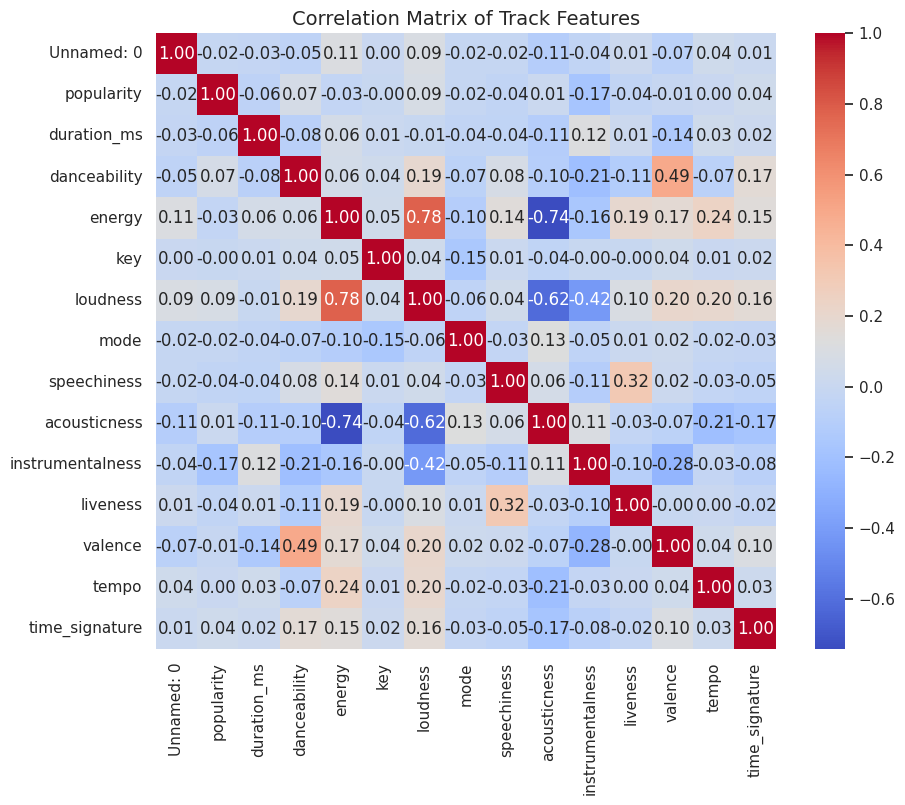

In [5]:
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix of Track Features', fontsize=14)
plt.savefig('chart2_correlation_heatmap.png', bbox_inches='tight')
plt.show()

Insight: Strong positive correlation exists between loudness and energy, whereas loudness and acousticness show a strong inverse relationship.

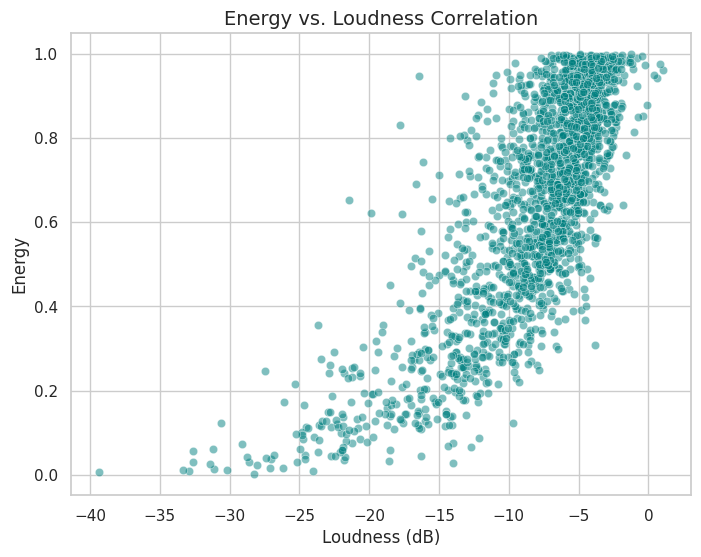

In [6]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df.sample(2000), x='loudness', y='energy', alpha=0.5, color='teal')
plt.title('Energy vs. Loudness Correlation', fontsize=14)
plt.xlabel('Loudness (dB)')
plt.ylabel('Energy')
plt.savefig('chart3_energy_vs_loudness.png', bbox_inches='tight')
plt.show()

Insight: Higher energy tracks consistently exhibit higher decibel levels, demonstrating that loudness is a major physical driver of perceived musical energy.

/tmp/ipykernel_739/2401869892.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=filtered_df, x='track_genre', y='popularity', palette='Set2')


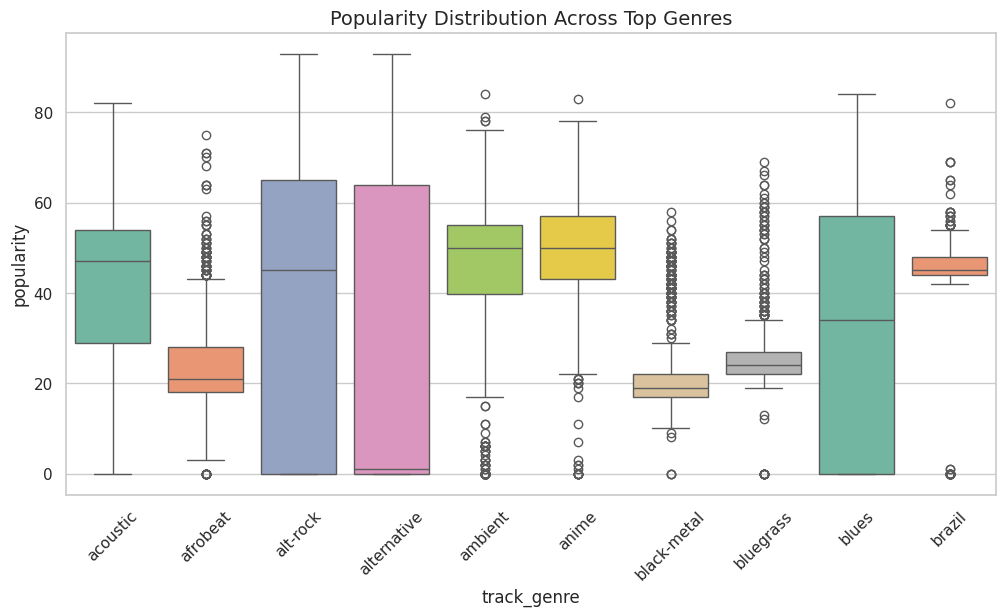

In [7]:
top_genres = df['track_genre'].value_counts().head(10).index
filtered_df = df[df['track_genre'].isin(top_genres)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=filtered_df, x='track_genre', y='popularity', palette='Set2')
plt.title('Popularity Distribution Across Top Genres', fontsize=14)
plt.xticks(rotation=45)
plt.savefig('chart4_genre_popularity_boxplot.png', bbox_inches='tight')
plt.show()

Insight: Certain genres display significantly higher median popularity scores and tighter interquartile ranges, indicating consistent listener engagement compared to niche genres.

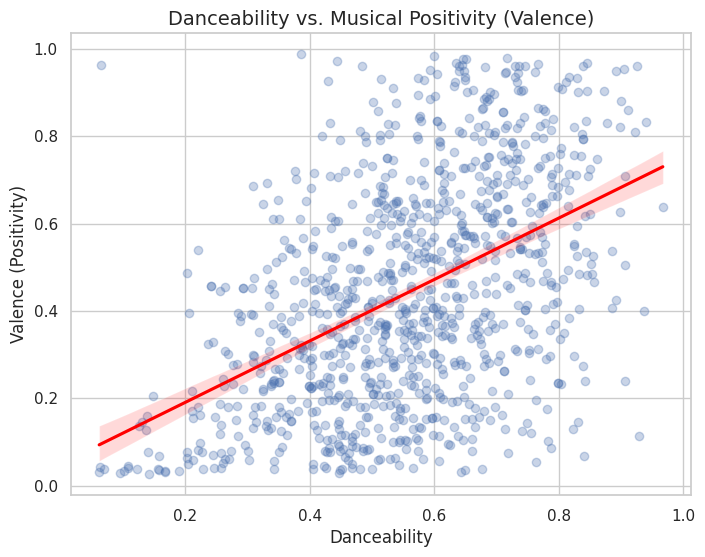

In [8]:
plt.figure(figsize=(8, 6))
sns.regplot(data=df.sample(1000), x='danceability', y='valence', scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'})
plt.title('Danceability vs. Musical Positivity (Valence)', fontsize=14)
plt.xlabel('Danceability')
plt.ylabel('Valence (Positivity)')
plt.savefig('chart5_danceability_vs_valence.png', bbox_inches='tight')
plt.show()

Insight: A positive linear trend shows that tracks engineered to be danceable generally convey happier, higher-valence musical tones.

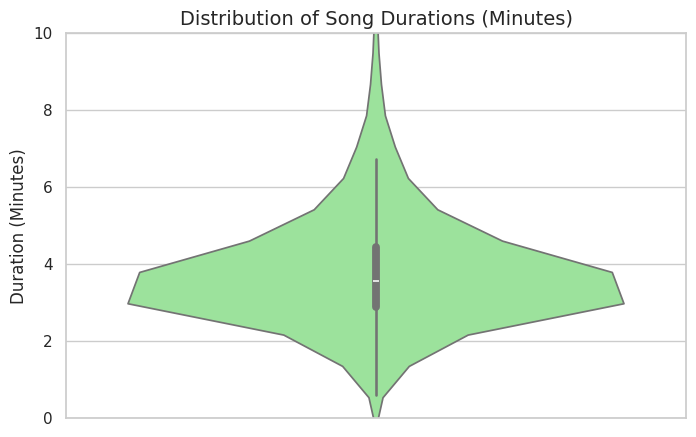

In [9]:
plt.figure(figsize=(8, 5))
sns.violinplot(y=df['duration_ms'] / 60000, color='lightgreen')
plt.title('Distribution of Song Durations (Minutes)', fontsize=14)
plt.ylabel('Duration (Minutes)')
plt.ylim(0, 10)
plt.savefig('chart6_duration_violin.png', bbox_inches='tight')
plt.show()

Insight: Most songs cluster tightly around the 3-to-4-minute mark, reflecting industry standards optimized for streaming and radio playback.

In [10]:
from google.colab import files

image_files = [
    'chart1_popularity_dist.png',
    'chart2_correlation_heatmap.png',
    'chart3_energy_vs_loudness.png',
    'chart4_genre_popularity_boxplot.png',
    'chart5_danceability_vs_valence.png',
    'chart6_duration_violin.png'
]

for img in image_files:
    files.download(img)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>